# Iteration 0 of History Matching for a stochastic SIR model

In this example, we assume that prevalence has been observed at two distinct times.  For iteration 0, we will "cut" down parameter space using only the observation of prevalence at the first time point.

In [1]:
# First load some libraries, including History Matching
%load_ext autoreload
%autoreload 2

import os
import glob
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wand.image import Image as WImage
from IPython.display import display

from pyDOE import lhs
from history_matching import HistoryMatching, HistoryMatchingCut, quick_read, Basis

sys.path.append("..") # Adds higher directory to python modules path.
from sir import SIR
import pycuda

/usr/lib/python3.7/site-packages/skcuda/cublas.py:283: UserWarning: creating CUBLAS context to get version number
  warnings.warn('creating CUBLAS context to get version number')


### Configure parameters and data for History Matching

In [2]:
iteration = int(re.search(r'iter(\d+)', os.getcwd()).group(1)) # Index of the current iteration

In [3]:
# The implausibility threshold determines how willing we are to retain regions
# of parameter space that are inconsistent with the underlying data. A higher
# threshold is more risk averse in that potentially good regions are less likely
# to be rejected, however it will take more iterations/simulations to achieve results.
implausibility_threshold = 3

n_samples_this_iter = 100 # Number of simulations to conduct on this iteration
n_samples_to_generate_for_next_iter = 100 # Number of simulations to conduct on this iteration

training_fraction = 0.75 # Fraction of simulations to use as training
discrepancy_std = 3 # Accounts for uncertainty w.r.t model structure

In [4]:
# Observed data
observations = pd.DataFrame({
    'Times': [3, 15],
    'Prevalence': [15, 40],
    'Stdev': [4, 2.3],
})
display(observations)

# For this first iteration, we're going to make one "cut" using the first observation, but 
# you can separately do multiple "cuts" per iteration using several obervations (separately)
# We'll need a name for this cut and the desired results

desired_result_idx = 0 # Pick observation 0 or 1 [integers]

cut_name = 'Prevalence_Meas_%d'%desired_result_idx # No spaces or strange characters!

desired_result = observations.iloc[desired_result_idx]['Prevalence']
desired_result_var = observations.iloc[desired_result_idx]['Stdev']**2

,Times,Prevalence,Stdev
0,3,15,4.0
1,15,40,2.3


In [5]:
# Here we define the parameter names and ranges
param_info = pd.DataFrame({
    'Name':['Beta', 'Gamma'],
    'Min':[1e-6, 1e-6],
    'Max':[0.01, 0.5]
}).set_index('Name')
params = param_info.index.values
n_params = param_info.shape[0] # We'll use this one place later
display(param_info)

,Min,Max
Name,,
Beta,0.000001,0.01
Gamma,0.000001,0.50


### Make some plots just for fun

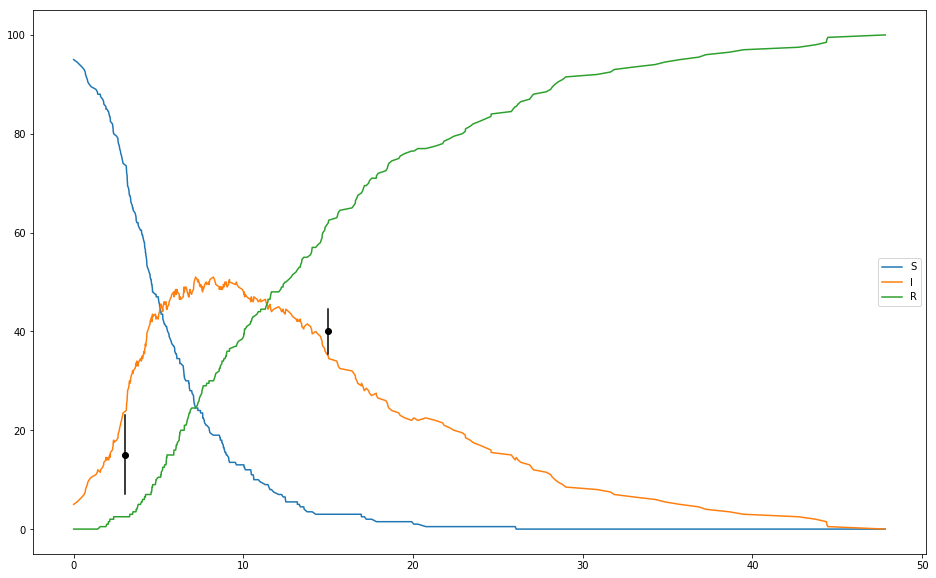

In [6]:
# Just for fun, let's visualize some SIR trajectories and observations / target data
z = SIR(beta=0.003, gamma=0.1)
f, ax = z.plot()
for i,obs in observations.iterrows():
    ax.plot(obs['Times'], obs['Prevalence'], 'ko')
    ax.plot(
        [obs['Times'],obs['Times']], 
        [obs['Prevalence']-2*obs['Stdev'],obs['Prevalence']+2*obs['Stdev']],
        'k-')

### Select and run simulation for this first iteration, also process and plot results

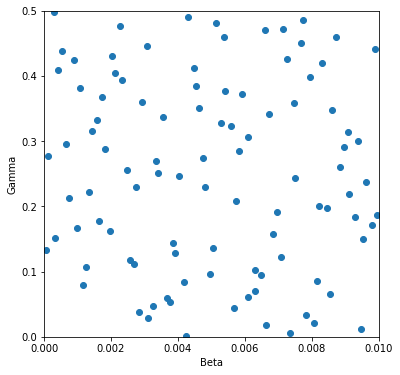

In [7]:
# For the first iteration, the samples are random.  We'll use Latin Hypercube Sampling
# to make the samples more uniformly random.
# samples should be a pandas data frame, and must have an index named 'Sample_Id'
samples = pd.DataFrame(lhs(n_params, n_samples_this_iter), columns=param_info.index.values)
samples.index.name = 'Sample_Id'

# The LHS samples are on range 0-1, let's stretch to the real parameter ranges
for param_name, values in samples.iteritems():
    samples[param_name] = \
        param_info.loc[param_name,'Min'] + \
        values*(param_info.loc[param_name,'Max']-param_info.loc[param_name,'Min'])

# Plot the samples
f, ax = plt.subplots(figsize=(6,6));
ax.scatter(x=samples[param_info.index.values[0]], y=samples[param_info.index.values[1]]);
ax.set_xlim([param_info['Min'][0], param_info['Max'][0]]);
ax.set_ylim([param_info['Min'][1], param_info['Max'][1]]);
ax.set_xlabel(param_info.index.values[0]);
ax.set_ylabel(param_info.index.values[1]);

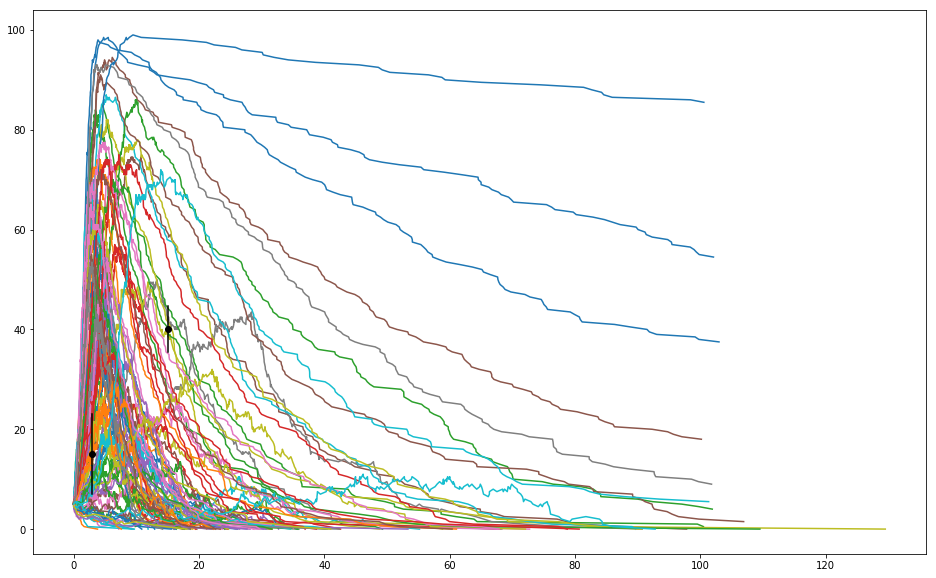

In [8]:
# Run the simulations specified by the samples and plot the results

f = plt.figure(figsize=(16,10))
sim_results = []
for idx, sample in samples.iterrows():
    z = SIR(beta=sample['Beta'], gamma=sample['Gamma'])
    T,_,P = z.sim() # Run the simulation
    prevalence = [p[1] for p in P] # Analyze the simulation to get the prevalence
    
    # Because we used SSA, the time vector T does not contain the prevalence at the 
    # exact observation time, t_obs.  Let's find the first measurement after t_obs
    # Here I'm getting both observations, but we really only need one
    for i, t_obs in enumerate(observations['Times']):
        value = next((p[1] for t,p in zip(T,P) if t>t_obs), None)
        if not value:
            value = P[-1][1]
        sim_results.append([idx, i, t_obs, value])
    
    # Plot
    plt.plot(T,prevalence)

# Convert sim_results into a pandas DataFrame
sim_results = pd.DataFrame(sim_results, columns=['Sample_Id', 'ObsIdx', 'ObsTime', 'Prevalence'])

# Simulation results will ultimately need a 'Sample_Id' and 'Sim_Id'
# The Sample_Id corresponds to the index in the samples dataframe above
# You can do more than one replicate of each sample, in which case you'd
# end up wiht more than one Sim_Id per Sample_Id.  We're not doing that here,
# so we can basically set Sim_Id to anything.
sim_results['Sim_Id'] = sim_results['Sample_Id']
    
# Plot the observations over the realized trajectories
for i,obs in observations.iterrows():
    plt.plot(obs['Times'], obs['Prevalence'], 'ko')
    plt.plot(
        [obs['Times'],obs['Times']], 
        [obs['Prevalence']-2*obs['Stdev'],obs['Prevalence']+2*obs['Stdev']],
        'k-')

In [9]:
# sim_results contains the simulated values at both observation times, but for this iteration
# we only want to use the first one (ObsIdx == 0).
# Also note that results must be a Series with index containing 'Sample_Id' and 'Sim_Id'
results = sim_results \
    .query('ObsIdx==%d'%desired_result_idx)[['Sample_Id', 'Sim_Id', 'Prevalence']] \
    .set_index(['Sample_Id', 'Sim_Id'])['Prevalence']
display(results.tail())

Sample_Id  Sim_Id
95         95        53.5
96         96        63.0
97         97        52.0
98         98         3.0
99         99         7.5
Name: Prevalence, dtype: float64

## Now begins History Matching!
### First step is to emulate the selected simulation output

In [10]:
# Finally we get to do some History Matching!

# Begin by creating an instance of the HistoryMatching class
hm = HistoryMatching(
    cut_name = cut_name,
    param_info = param_info,
    inputs = samples,
    results = results,
    desired_result = desired_result,
    desired_result_var = desired_result_var,
    iteration = iteration,
    implausibility_threshold = implausibility_threshold,
    discrepancy_var = discrepancy_std**2,
    training_fraction = training_fraction
)
hm.save() # Save to disk


Welcome to IDM History Matching!
Found 100 unique parameter configurations, each of which is repeated 1 time(s).
--> Training with 75 unique parameter configurations ( 75  simulations including replicates)
--> Testing  with 25  unique parameter configurations ( 25 simulations including replicates)


In [11]:
# Now we begin the process of emulating the simulation output
# This process contains two steps.  The first step is to fit a deterministic model, here
# we use a generalized linear model (GLM).  The glm will attempt to model the output (prevalence 
# at the first observation) as a function of some inputs.  Those inputs need not be the model
# parameters directly!  The inputs could be anything from a constant intercept up to third or higher
# order interaction terms between parameters.  The following Basis instance builds out the GLM input
# parameters from the overall simulation input parameters.
#
# Some strategy is required when choosing these.  If you know which parameters matter, there's a way
# to directly specify those parameters.  Alternatively, if you have no idea, you can initially include 
# an intercept, first, second, and maybe also third order interaction terms.  The Basis class has a 
# built-in penalized regression that throws away unneeded terms (basis vectors).
# The second step of emulation, as demonstrated here, fits a GPR to the redisual error between the 
# simulated outputs and the GLM estimates.  If the GLM fits really well, the residual is mostly noise and
# the GPR has a hard time fitting / isn't very informative.  I actually prefer to weaken the GLM enough
# to leave plenty of residual signal for the GPR.  Here, I use only first-order (beta and gamma) terms.
basis_glm = Basis.make_polynomial_basis(
    params = param_info.index.values,
    intercept = True,
    first_order = True,
    second_order = False,
    third_order = False,
    param_info = param_info)

In [12]:
# Now fit the glm and plot

### GLM ###############################################################
print("="*80, "\nGeneralized Linear Modeling\n", "="*80)
#######################################################################
f = hm.glm(
    basis = basis_glm,
    family = 'Gaussian',
    force_optimize_glm = True,
    glm_fit_maxiter = 100000,
    plot = True, #force_optimize_glm,
    plot_data = True
)

Generalized Linear Modeling
Using Gaussian family
Fitting the GLM
Fitting the model, please wait ...
                 Generalized Linear Model Regression Results                  
Dep. Variable:             Sim_Result   No. Observations:                   75
Model:                            GLM   Df Residuals:                       72
Model Family:                Gaussian   Df Model:                            2
Link Function:               identity   Scale:                          75.099
Method:                          IRLS   Log-Likelihood:                -266.85
Date:                Mon, 20 May 2019   Deviance:                       5407.2
Time:                        11:21:27   Pearson chi2:                 5.41e+03
No. Iterations:                     3   Covariance Type:             nonrobust
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.2178      2.8

../iter0/Cuts/Prevalence_Meas_0/GLM/PairwiseResults/Beta-Gamma.pdf


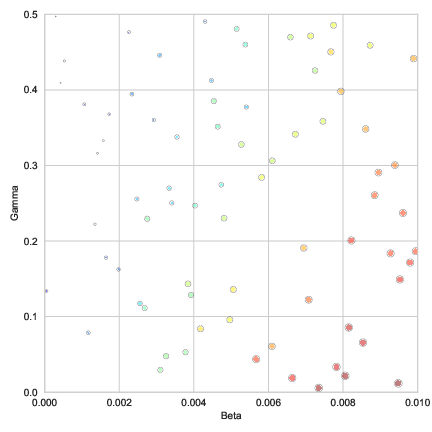

In [13]:
for file in glob.glob(os.path.join(hm.glmdir, "PairwiseResults", "*.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

../iter0/Cuts/Prevalence_Meas_0/GLM/GLM Predicted vs Actual.pdf


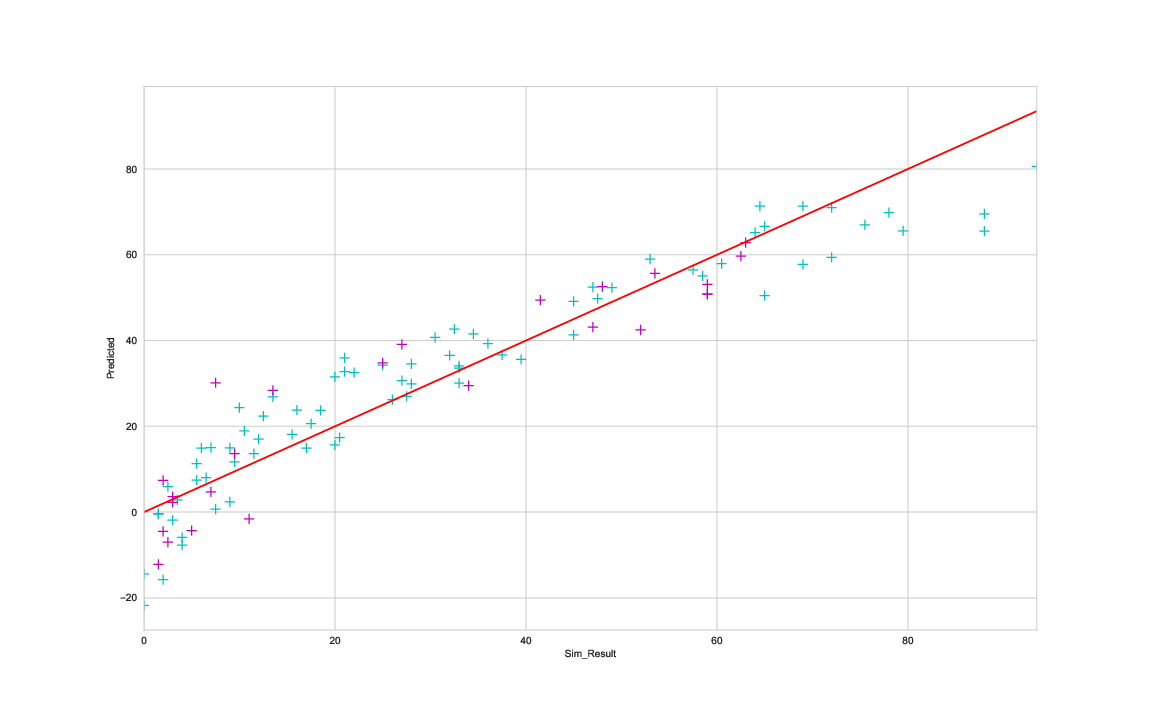

In [14]:
# Results get saved to disk, so load and display:
for file in glob.glob(os.path.join(hm.glmdir, "GLM Predicted vs Actual.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

In [15]:
basis_gpr = Basis.make_polynomial_basis(
    params=param_info.index.values, 
    intercept = False, 
    first_order=True, 
    param_info=param_info)

In [16]:
### GPR ###############################################################
print("="*80, "\nGaussian Process Regression\n", "="*80)
#######################################################################
hm.gpr(
    basis = basis_gpr,
    force_optimize_gpr = True,

    sigma2_f_guess = 0.6,
    sigma2_f_bounds = (0.1, 1000),
    sigma2_n_guess =  2.0,
    sigma2_n_bounds = (0.01, 100),

    #lengthscale_guess = [0.09844299, 0.1256657, 0.0976875, 0.09889085, 0.1051974, 0.0950809, 0.10032171, 0.10599185, 0.10627393, 0.09950996, 0.09445544, 0.10285915, 0.10007409, 0.09847433, 0.08963389, 0.10205652, 0.09360044, 0.1024141, 0.09786228, 0.10247492, 0.09852253, 0.09632744, 0.09997534, 0.10767302, 0.10095249, 0.09941825, 0.10214923, 0.10221497, 0.09734157, 0.09093285, 0.10780673, 0.09881377, 0.10597152],
    lengthscale_guess = 0.25,
    lengthscale_bounds = (0.01, 100),

    optimize_sigma2_n = True,
    log_transform = False,

    optimizer_options = {
        'eps': 5e-3,
        'disp': True,
        'maxiter': 15000,
        'ftol': 2 * np.finfo(float).eps,
        'gtol': 2 * np.finfo(float).eps,
    },
    plot = True, #force_optimize_gpr,
    plot_data = True
)


Gaussian Process Regression
Autoinit GPU device name: Tesla K80
max_threads_per_block 1024
max_block_dim (1024, 1024, 64)
max_grid_dim (2147483647, 65535, 65535)
max_blocks_per_grid 2147483647
block_dim (1024, 1, 1)
grid_dim (6, 1, 1)
Backing up gpr model to ../iter0/Cuts/Prevalence_Meas_0/GPR/model_2019_05_20_11_21_28.json
Fitting the GPR

	LL: 108.06390477493349 
	Theta: [0.6  2.   0.25 0.25] 
	Deriv: [-4.165432   14.42252991  6.94127811  5.26919427]

	LL: 224.49202433713396 
	Theta: [4.765432 0.01     0.01     0.01    ] 
	Deriv: [-2.20167470e+01 -4.59200102e+03  2.13217940e+04  3.31924537e+04]

	LL: 107.79606094889544 
	Theta: [0.62293199 1.98904443 0.24867873 0.24867873] 
	Deriv: [-3.96313707 14.53581799  6.93186475  5.1217532 ]

	LL: 86.80975199659542 
	Theta: [2.69418199 0.99952222 0.12933936 0.12933936] 
	Deriv: [  0.10643424  24.79395599  -0.22062035 -12.11247187]

	LL: 75.87494143337926 
	Theta: [4.061207   0.34643755 0.05057538 0.05057538] 
	Deriv: [   0.81712923    6.1967420

../iter0/Cuts/Prevalence_Meas_0/GPR/PairwiseResults/Beta-Gamma.pdf


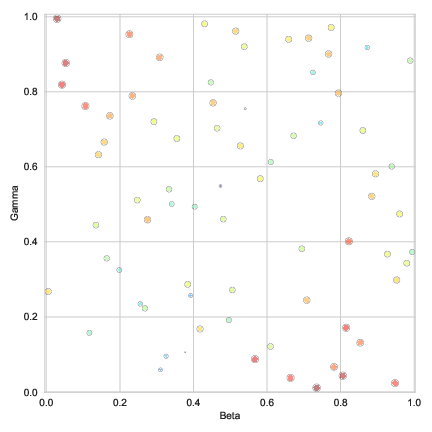

In [17]:
# Results get saved to disk, so load and display:
for file in glob.glob(os.path.join(hm.gprdir, "PairwiseResults", "*.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

../iter0/Cuts/Prevalence_Meas_0/GPR/gpr.pdf


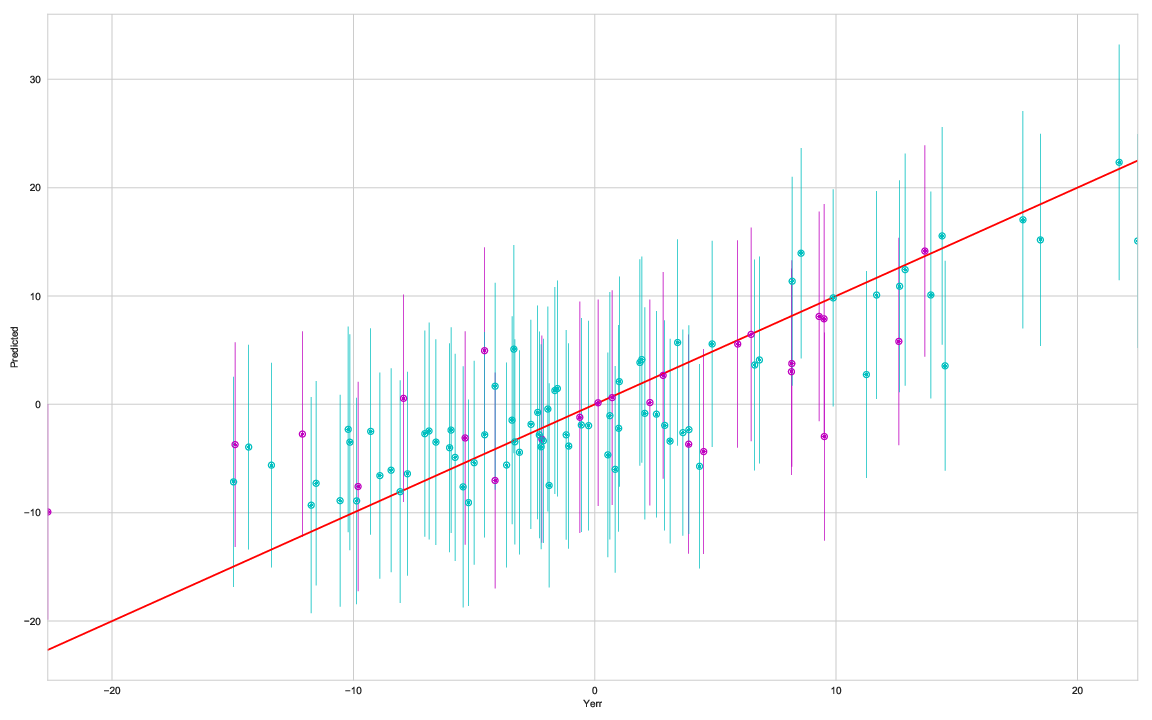

In [18]:
# Results get saved to disk, so load and display:
for file in glob.glob(os.path.join(hm.gprdir, "gpr.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

## Check the fit of the overall (GLM+GPR) emulator

../iter0/Cuts/Prevalence_Meas_0/emulation.pdf


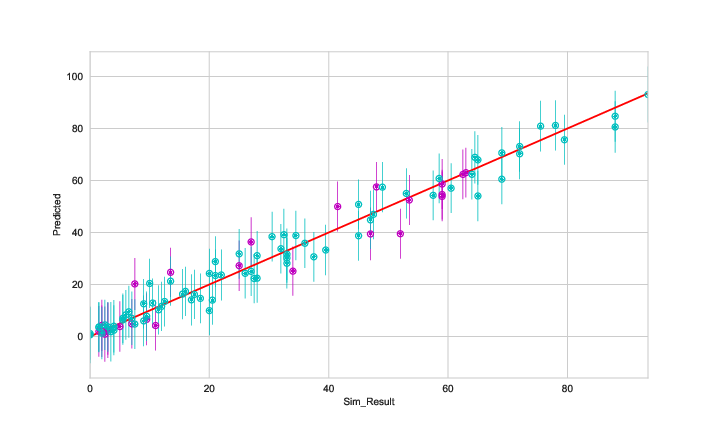

In [19]:
hm.plot()
# Results get saved to disk, so load and display:
for file in glob.glob(os.path.join(hm.cutdir, "emulation.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

### Now use the emulator to calculate "implausibility."  New simulations will not be commissioned on future iterations where implasibility is high.

In [20]:
### Implausibility ############################################################
print("="*80, "\nImplausibility\n", "="*80)
###############################################################################
hm.calc_and_plot_implausibility(
    plot = True,
    do_plot_data = True,
    plot_data_highlight = pd.DataFrame() #hm.test_data.loc['prime.000049']
) 
    #plot_data_highlight=pd.DataFrame() # plot_data_highlight=hm.training_data.loc['prime.000049']

hm.training_data.to_excel(os.path.join('Cuts', cut_name, 'train_data.xlsx'))
hm.test_data.to_excel(os.path.join('Cuts', cut_name, 'test_data.xlsx'))

print('Good')

Implausibility
Good


../iter0/Cuts/Prevalence_Meas_0/Implausibility/PairwiseResults/Train/Beta-Gamma.pdf


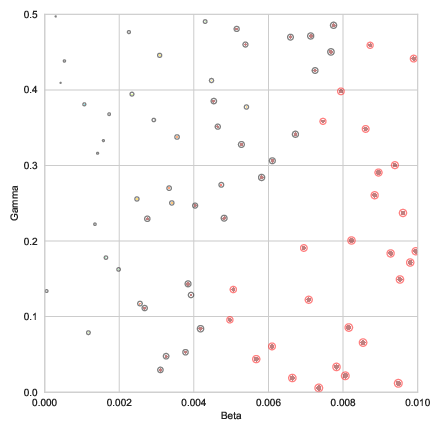

../iter0/Cuts/Prevalence_Meas_0/Implausibility/PairwiseResults/Test/Beta-Gamma.pdf


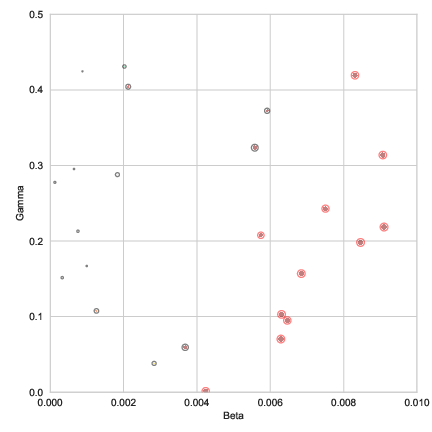

In [21]:
# Results get saved to disk, so load and display:
for file in glob.glob(os.path.join(hm.combineddir, "PairwiseResults", "*", "*.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

../iter0/Cuts/Prevalence_Meas_0/Implausibility/implausibility.pdf


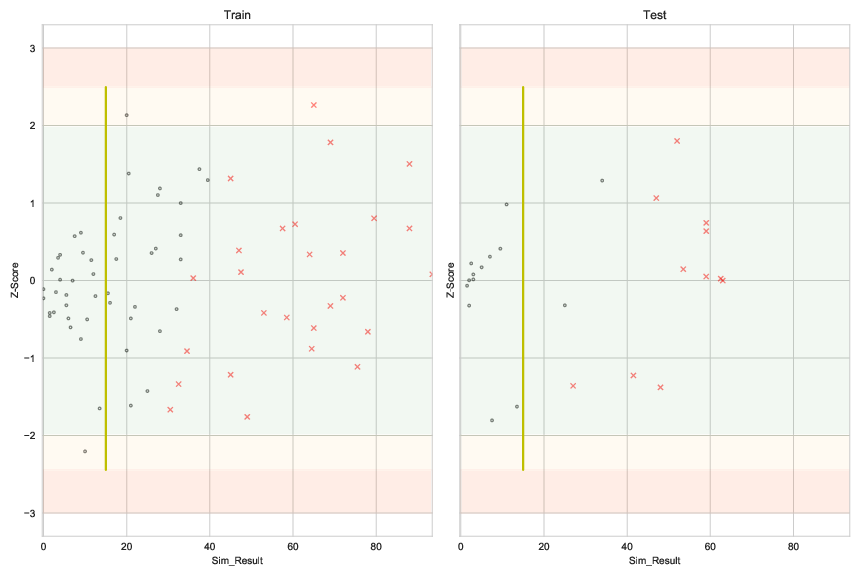

In [22]:
# Results get saved to disk, so load and display:
from wand.image import Image as WImage
import glob, os
from IPython.display import display
for file in glob.glob(os.path.join(hm.combineddir, "*.pdf")):
    img = WImage(filename=file)
    print(file)
    display(img)

## Select samples for the next iteration
Now that the emulators are fit, it's time to select samples for the next iteration.
Here we use a class called HistoryMatchingCut.  It's job is to conduct rejection sampling in order to find n_samples_per_iteration new samples that are not implausible with respect to the emulation on this wave or any previous wave.  Resulting samples are saved to disk, so we'll load them in just to make a plot.

In [23]:
### Cut #######################################################################
print("="*80, "\nCut\n", "="*80)
###############################################################################
# History Matching!
hmc = HistoryMatchingCut(
    cut_dir = 'Cuts',
    iteration = int(re.search(r'iter(\d+)', os.getcwd()).group(1))
)

(_, rejected_percent) = hmc.cut(num_desired_candidates=n_samples_to_generate_for_next_iter, constraint = None)

Cut
Reading iteration 0 . cut Prevalence_Meas_0
Welcome to IDM History Matching!
Found 100 unique parameter configurations, each of which is repeated 1 time(s).
--> Training with 75 unique parameter configurations ( 75  simulations including replicates)
--> Testing  with 25  unique parameter configurations ( 25 simulations including replicates)
	 Desired Result: 15
	 Desired Result Var: 0
	 Discrepancy Var: 9
	 Imp Thresh: 3
Using Gaussian family
                 Generalized Linear Model Regression Results                  
Dep. Variable:             Sim_Result   No. Observations:                   75
Model:                            GLM   Df Residuals:                       72
Model Family:                Gaussian   Df Model:                            2
Link Function:               identity   Scale:                          75.099
Method:                          IRLS   Log-Likelihood:                -266.85
Date:                Mon, 20 May 2019   Deviance:                       540

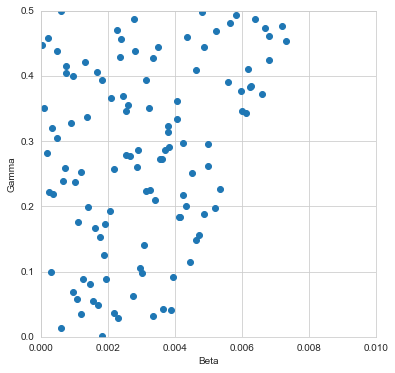

In [24]:
# Samples for the next iteration are saved to file, in this case it's "Candidates_for_iter1.csv"
# Just to see what they look like, we'll read that file and plot the samples
# Notice how the entire bottom right of the paramter space is empty?  Those points were rejected!

samples = pd.read_csv('Candidates_for_iter%d.csv'%(iteration+1))

f, ax = plt.subplots(figsize=(6,6))
ax.scatter(x=samples[param_info.index.values[0]], y=samples[param_info.index.values[1]])
ax.set_xlim([param_info['Min'][0], param_info['Max'][0]])
ax.set_ylim([param_info['Min'][1], param_info['Max'][1]])
ax.set_xlabel(param_info.index.values[0])
ax.set_ylabel(param_info.index.values[1]);

# Now move into the iter1 directory to continue with the next iteration of this example!